In [1]:
!pip install PyWavelets

Dataset Shape: (3000, 28, 28)


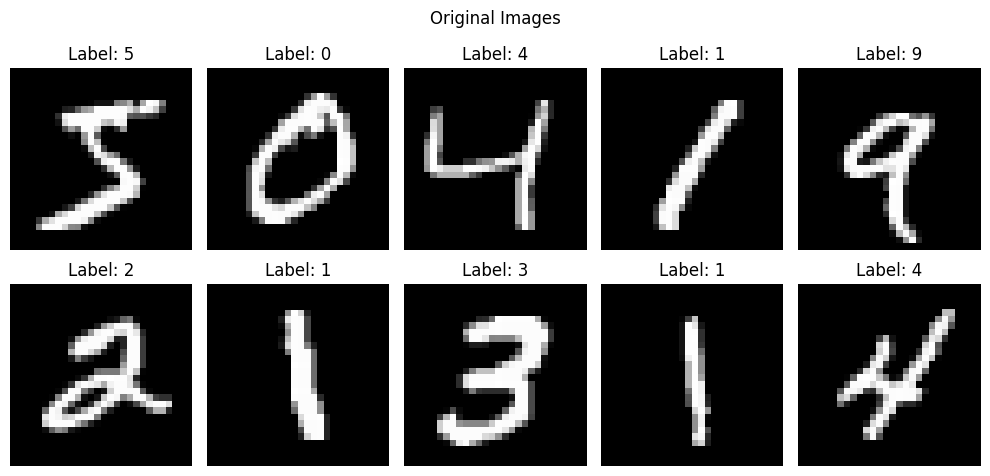

Feature Shape: (3000, 784)


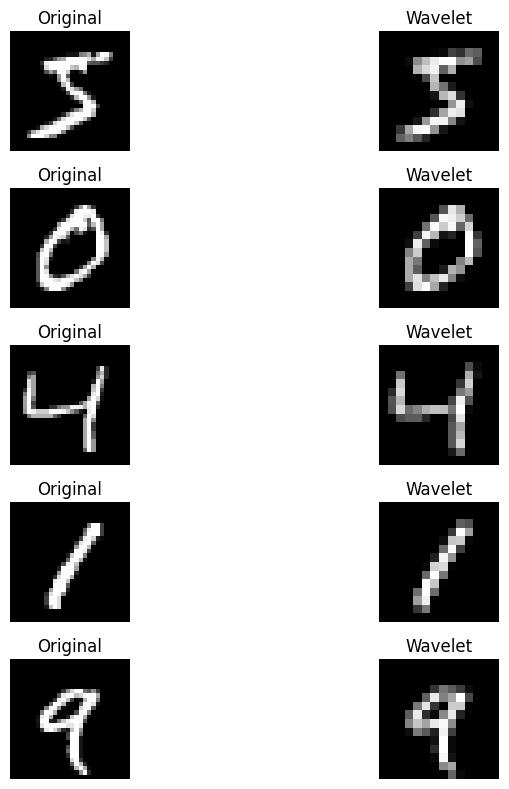

After PCA: (3000, 50)


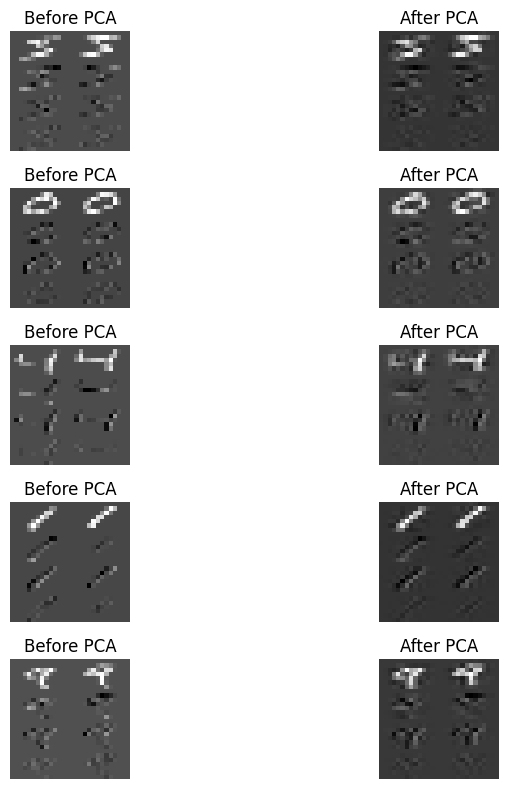

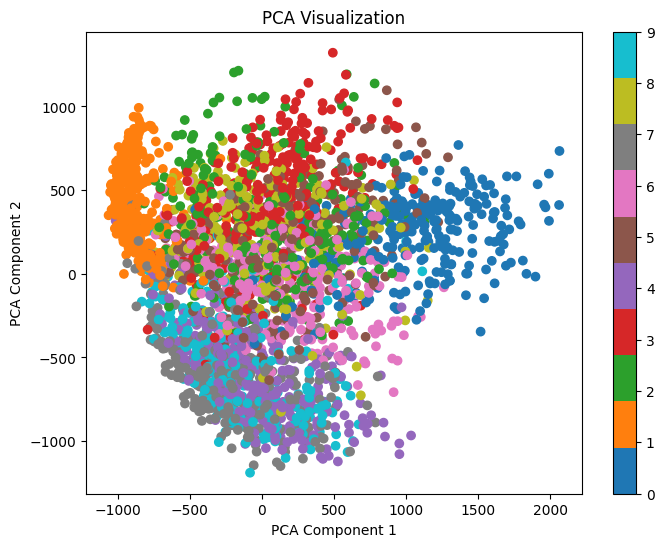


Accuracy: 0.97

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        56
           1       1.00      0.97      0.99        75
           2       0.94      0.96      0.95        50
           3       0.95      0.98      0.97        63
           4       0.98      0.97      0.98        61
           5       0.96      0.98      0.97        51
           6       0.98      1.00      0.99        61
           7       0.97      0.97      0.97        60
           8       0.98      0.95      0.96        57
           9       0.95      0.94      0.95        66

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



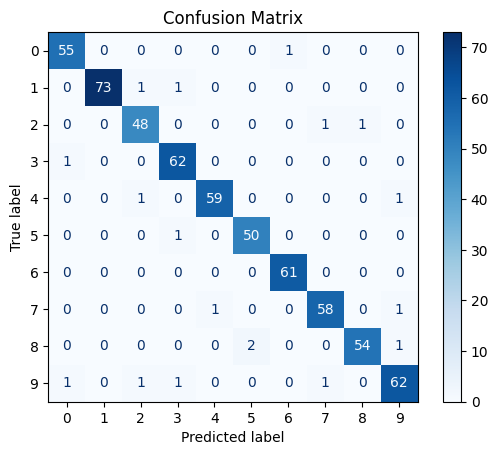

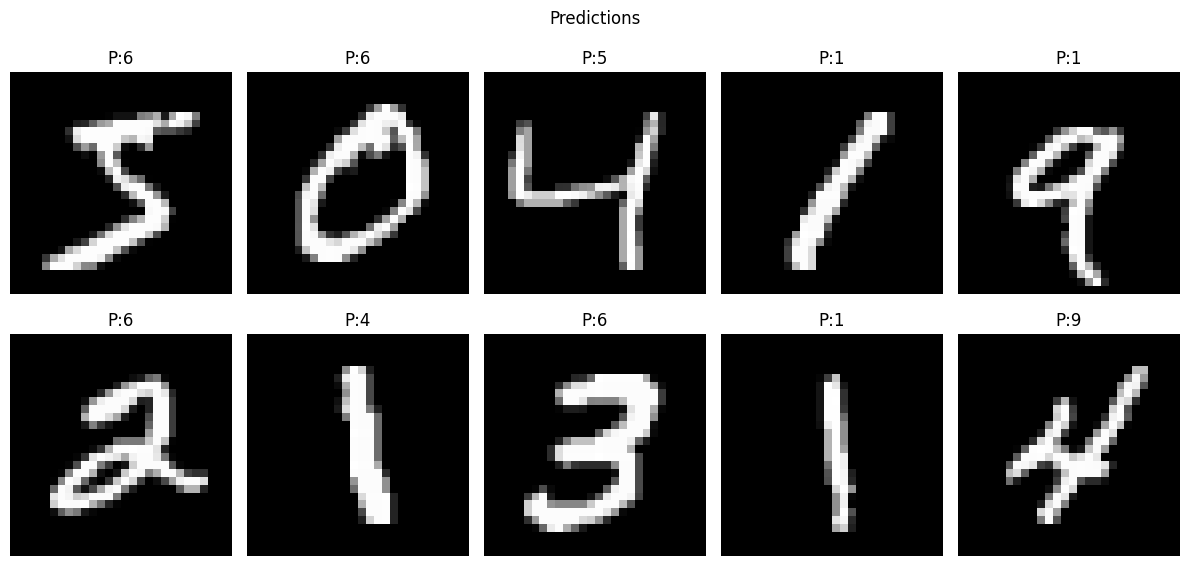


Project Completed Successfully!


In [9]:
# ==========================================
# MNIST Digit Recognition using
# Wavelet Transform + PCA + SVM
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import pywt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# =========================
# Load MNIST Dataset
# =========================

mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.to_numpy()
y = mnist.target.astype(int)

# Reduce dataset size for faster execution
X = X[:3000]
y = y[:3000]

# Reshape to images
images = X.reshape(-1, 28, 28)

print("Dataset Shape:", images.shape)

# =========================
# Show Original Images
# =========================

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i], cmap='gray')

    plt.title(f"Label: {y[i]}")

    plt.axis('off')

plt.suptitle("Original Images")

plt.tight_layout()

plt.show()

# =========================
# Wavelet Transform
# =========================

features = []
wavelet_images = []

for img in images:

    coeffs = pywt.dwt2(img, 'haar')

    LL, (LH, HL, HH) = coeffs

    wavelet_images.append(LL)

    feature_vector = np.concatenate([
        LL.flatten(),
        LH.flatten(),
        HL.flatten(),
        HH.flatten()
    ])

    features.append(feature_vector)

features = np.array(features)

print("Feature Shape:", features.shape)

# =========================
# Show Wavelet Images
# =========================

plt.figure(figsize=(10,8))

for i in range(5):

    # Original
    plt.subplot(5,2,2*i+1)

    plt.imshow(images[i], cmap='gray')

    plt.title("Original")

    plt.axis('off')

    # Wavelet
    plt.subplot(5,2,2*i+2)

    plt.imshow(wavelet_images[i], cmap='gray')

    plt.title("Wavelet")

    plt.axis('off')

plt.tight_layout()

plt.show()

# =========================
# PCA
# =========================

pca = PCA(n_components=50)

X_pca = pca.fit_transform(features)

print("After PCA:", X_pca.shape)

# =========================
# PCA Reconstruction
# =========================

X_reconstructed = pca.inverse_transform(X_pca)

# =========================
# Show Before and After PCA
# =========================

plt.figure(figsize=(10,8))

for i in range(5):

    # Before PCA
    plt.subplot(5,2,2*i+1)

    plt.imshow(features[i].reshape(28,28), cmap='gray')

    plt.title("Before PCA")

    plt.axis('off')

    # After PCA
    plt.subplot(5,2,2*i+2)

    plt.imshow(X_reconstructed[i].reshape(28,28), cmap='gray')

    plt.title("After PCA")

    plt.axis('off')

plt.tight_layout()

plt.show()

# =========================
# PCA Visualization
# =========================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='tab10'
)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.title("PCA Visualization")

plt.colorbar(scatter)

plt.show()

# =========================
# Train/Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# SVM Classification
# =========================

model = SVC()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# =========================
# Accuracy
# =========================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# =========================
# Classification Report
# =========================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

# =========================
# Prediction Examples
# =========================

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i], cmap='gray')

    plt.title(f"P:{y_pred[i]}")

    plt.axis('off')

plt.suptitle("Predictions")

plt.tight_layout()

plt.show()

print("\nProject Completed Successfully!")